# Machine Learning in Python (AI Generated)

This notebook was generated via AI prompting to build a complete ML workflow on the Iris dataset.


In [1]:
%matplotlib inline
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC


In [2]:
df = pd.read_csv('iris.csv')
print(f'Data loaded: {df.shape[0]} rows, {df.shape[1]} columns')


Data loaded: 150 rows, 5 columns


In [3]:
print('Shape:', df.shape)
df.head()


Shape: (150, 5)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [4]:
df.describe()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [5]:
df.groupby('species').size()


species
0    50
1    50
2    50
dtype: int64

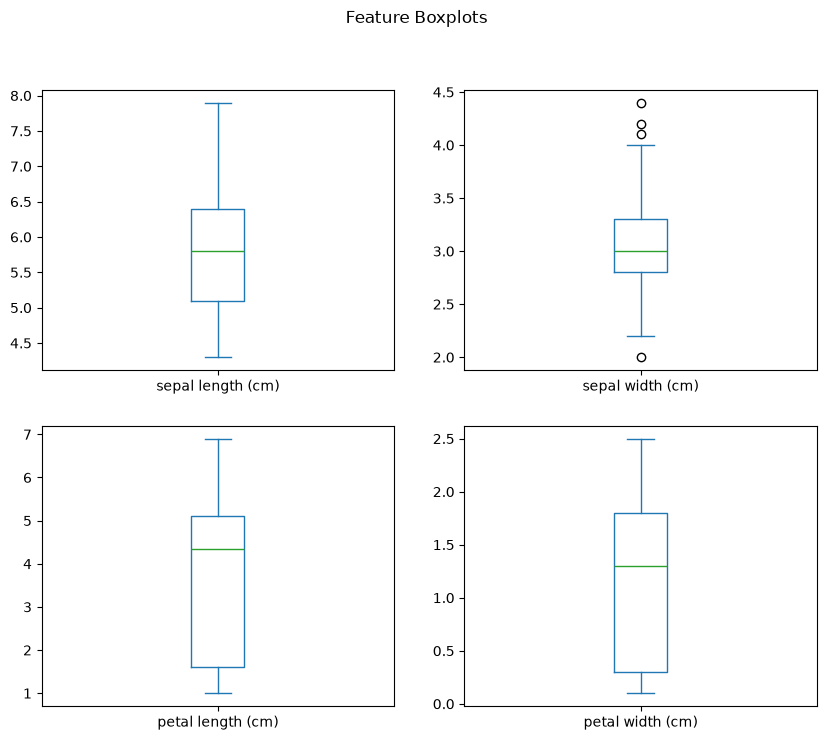

In [6]:
df.iloc[:, :4].plot(kind='box', subplots=True, layout=(2,2), figsize=(10,8))
plt.suptitle('Feature Boxplots')
plt.show()


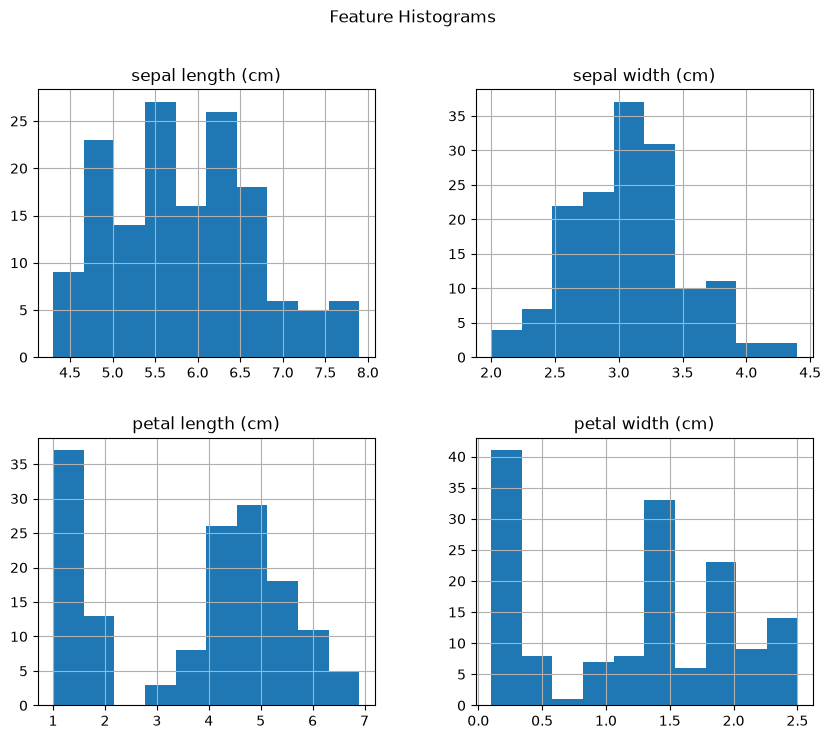

In [7]:
df.iloc[:, :4].hist(figsize=(10,8))
plt.suptitle('Feature Histograms')
plt.show()


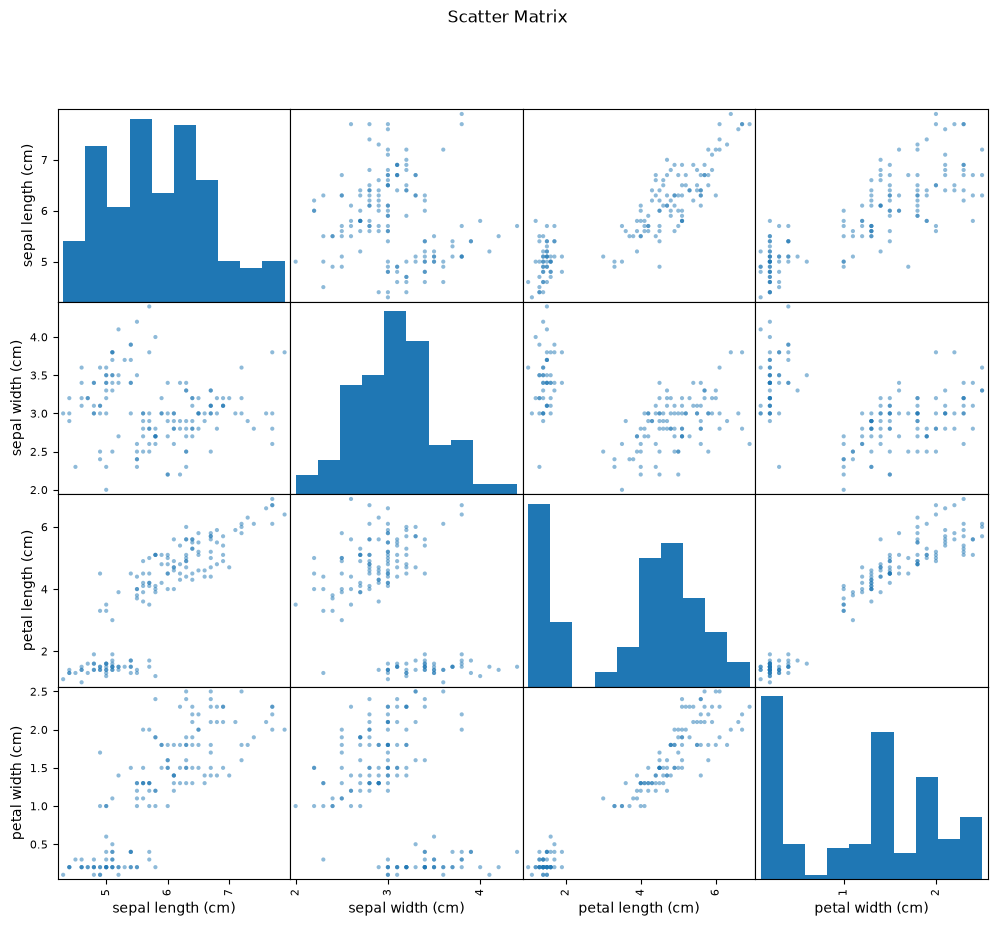

In [8]:
pd.plotting.scatter_matrix(df.iloc[:, :4], figsize=(12,10))
plt.suptitle('Scatter Matrix')
plt.show()


In [9]:
X = df.iloc[:, :4].values
y = df.iloc[:, 4].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)
models = {'LR': LogisticRegression(max_iter=200), 'LDA': LinearDiscriminantAnalysis(),
          'KNN': KNeighborsClassifier(), 'CART': DecisionTreeClassifier(),
          'NB': GaussianNB(), 'SVM': SVC(gamma='auto')}
for name, model in models.items():
    kfold = StratifiedKFold(n_splits=10, random_state=1, shuffle=True)
    cv = cross_val_score(model, X_train, y_train, cv=kfold, scoring='accuracy')
    print(f'{name}: {cv.mean():.4f} ({cv.std():.4f})')


LR: 0.9667 (0.0408)
LDA: 0.9750 (0.0382)
KNN: 0.9583 (0.0417)
CART: 0.9583 (0.0417)
NB: 0.9500 (0.0553)
SVM: 0.9833 (0.0333)


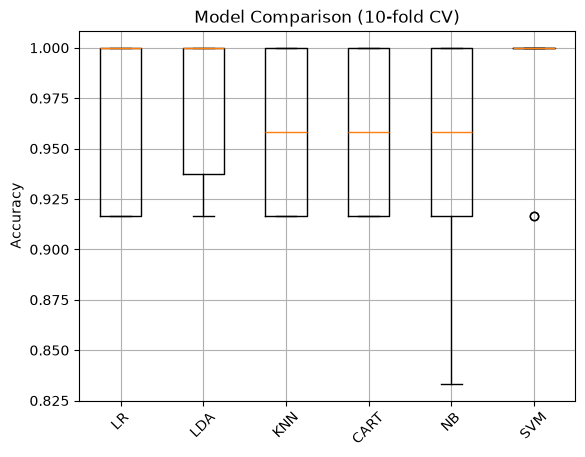

In [10]:
kfold = StratifiedKFold(n_splits=10, random_state=1, shuffle=True)
results = [cross_val_score(m, X_train, y_train, cv=kfold, scoring='accuracy') for m in models.values()]
plt.boxplot(results, tick_labels=list(models.keys()))
plt.title('Model Comparison (10-fold CV)')
plt.ylabel('Accuracy')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


In [11]:
best = SVC(gamma='auto').fit(X_train, y_train)
pred = best.predict(X_test)
print(f'Accuracy: {accuracy_score(y_test, pred):.4f}')
print(confusion_matrix(y_test, pred))
print(classification_report(y_test, pred))


Accuracy: 0.9667
[[11  0  0]
 [ 0 12  1]
 [ 0  0  6]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       1.00      0.92      0.96        13
           2       0.86      1.00      0.92         6

    accuracy                           0.97        30
   macro avg       0.95      0.97      0.96        30
weighted avg       0.97      0.97      0.97        30

